# Tutorial on time of arrival estimation under jitter noise

## Scenario Description

My project requires precise estimation of time delay or time of arrival (TOA) estimation to calculate bearing angles using microelectrode arrays (MEAs). Because the electrodes are placed in an array, each electrode should theoretically see a copy of this sourced signal with time delays. However, one perturbation in the real environment is thermal noise as a receiver characteristic, which results in random jitter. This jitter in time causes imprecise measurements of time delays. This work can be further applied to time difference of arrival (TDOA) applications.

## Introduction

Time of Arrival (TOA) estimation is a fundamental problem in localization. It involves determining the precise moment a signal, or a characteristic event within a signal, arrives at a sensor or detector. However, signals are often corrupted by various forms of uncertainty, collectively known as **jitter**. Jitter can be random or deterministic deviations in the timing of events from their ideal or expected instances. These timing variations can significantly degrade the accuracy of TOA estimates and, consequently, the performance of systems that rely on them.

This tutorial explores the concepts of correlation, its application in TOA estimation, and how **random** jitter influences this process. We will delve into the mathematical foundations and analyze the effects of applying cross-correlation for TOA estimation under random jitter. The case study will apply this function to micro electrode array processing on brain signals.

### Types of Jitter: Deterministic and Random

Timing jitter for signal processing can be classified into 2 main categories based on its statistical properties and underlying causes. This document primarily focuses on random jitter.



#### 1. Deterministic Jitter (DJ)

Deterministic jitter can be caused by crosstalk interference, 50/60 Hz power supply noise, and multipath. It is characterized as a signal that is bounded, predictable, and may be either periodic or aperiodic. Periodic jitter is easily visible in frequency domain.

---
#### 2. Random Jitter (RJ)

Random jitter is primarily caused by thermal noise. It is characterized as a signal contaminated by an unbounded probabilistic distribution - typically a gaussian distribution.

### Other causes of jitter
Below are other potential causes of jitter, under the lens of timing applications for surgically placed brain micro electrode arrays (MEA). However, these will not be expanded upon for this tutorial. We believe that interference from other signals would be the main core possible effects on jitter to investigate for brain signals.


#### 1. Interference / Crosstalk

Different propagating signals (other brain activity, artifacts) can affect array electrodes differently. Unlike thermal noise, interference is structured and may have spatial coherence.

Potential mitigation techniques include

**MVDR (Minimum Variance Distortionless Response):**
- Adaptive beamforming technique that attempts to minimize output variance while maintaining unity gain in the direction of interest
- Requires knowledge or estimation of the signal direction and interference/noise covariance

**MUSIC (Multiple Signal Classification):**
- Uses eigendecomposition to separate signal and noise subspaces
- Can estimate direction of arrival for multiple signals
- Requires multiple snapshots and assumptions about the number of signal sources

#### 2. Multipath Propagation

Multipath refers to the phenomenon where the transmitted signal reaches the receiver via multiple paths due to reflections, creating multiple delayed and attenuated copies of the signal.

#### 3. Synchronization Errors

Sampling oscillators between electrode channels must be synchronized to align receiver timing with transmitter. Imperfect estimation leads to residual timing errors. However, for multiple electrode systems, we can assume electrode channels are built to share one oscillator.

#### 4. Oscillator Instability

Clocks in signal processing systems can drift over time. However, as we should assume the electrode system shares one oscillator, they all receive the same drift. For many position finding frameworks, the exact arrival time is not required and only the relative arrival time must be accurate.

#### 5. ADC Aperture Jitter

Analog-to-Digital Converters can sample at slightly incorrect times due to aperture jitter however, ADC jitter is primarily significant for high-frequency signals or high sampling rate systems. Electrode collection systems rarely go beyond 2 KHz, as much of the signals carry information at lower frequencies.

---

#### Side Notes

As electrodes degrade, their impedance tends to increase, potentially creating a frequency-dependent filtering effect. This degradation may disproportionately attenuate high-frequency signal components compared to low-frequency ones. It's worth investigating whether electrode aging can affect detection performance.



## Random Jitter and Correlation

Prior to defining how to detect and estimate the jitter for signals, we define and prove where the ideas and techniques come from in theory.
In the next sections, you will see that the primary technique for delay estimation and signal detection comes from the correlation function.

### What Is Correlation?

In the prior section, we discussed how correlation between the original signal s[n] and the contaminated signal is the ML estimate for estimating the time delay. Time-of-arrival (ToA) problems require knowing when a signal arrived given by estimating the timing offset using correlation. Peak detection is used to determine relative delay between electrodes in an array.

Correlation measures the similarity between two signals as a function of time lag. It quantifies how much one signal resembles another (or itself) when shifted by a delay $\tau$.

For continuous-time signals $r(t)$ and $s(t)$, the cross-correlation function is:

$$
R_{rs}(\tau) = \int_{-\infty}^{\infty} r(t) s^*(t - \tau) \, dt
$$

For discrete-time signals (sampled data):

$$
R_{rs}[m] = \sum_{n=-\infty}^{\infty} r[n] s^*[n - m]
$$

where $s^*$ denotes the complex conjugate (for real signals, $s^* = s$) Moving fowards, we assume this signal is **real** and **discrete**.

### Simplified description on how to conceptualize detection and estimation

The background in how correlation comes into play for time-delay estimation is defined under detection and estimation theory. The jargon can be confusing, so this section distills the important components into digestible and (hopefully) friendly analogies.

---

#### Detection Theory

Our goal is to **decide** whether a signal is **present** in noisy data. The model is defined by the **null hypothesis** ($H_0$: noise only) and the **alternative hypothesis** ($H_1$: signal + noise). We assume **data** comes from either $H_0$ or $H_1$. When we receive data, we measure its attributes with a **test statistic**, then compare that measurement to a **threshold** that balances Type I errors (false alarms) and Type II errors (misses). The test statistic should be defined to enable analysis and reasoning about the model's properties.

To give an analogy, imagine $H_0$ represents "short people" and $H_1$ represents "tall people." We visually estimate height in inches, so our **test statistic is eyeballing height**. We must choose a **threshold** height (say, 68 inches). If someone appears taller than 68 inches, we classify them as "tall" ($H_1$); otherwise, "short" ($H_0$). How we choose the threshold matters: if heights under $H_0$ and $H_1$ are Gaussian distributed with equal variance, and the populations are equal in size, placing the threshold exactly at the **midpoint between the two means** minimizes the overall probability of being wrong. This is called a **Bayes detector**. Alternatively, we could set the threshold to guarantee we rarely call a short person tall (control false alarms), even if it means missing some tall people. This is the **Neyman-Pearson** approach. Whether this model is true or useful must be validated through testing and analysis!

#### Estimation Theory

Our goal is to **determine** the **value** of an unknown parameter such as time delay. The **parameter** is the unknown quantity we want to estimate ($\tau$, $A$, etc.). We observe **data** that depends on this unknown parameter, then design an **estimator**—a function that produces an estimate $\hat{\tau}$ from the data. The quality of the estimate is measured by a **performance metric** (e.g., mean squared error, bias, variance). The estimator should be designed to optimize some criterion (e.g., maximum likelihood, minimum variance).

Continuing our height analogy, after quickly eyeballing whether someone is tall or short (detection), suppose we want to measure their **exact height**. We have 3 people measure a person's height with tape measurers and carefully measure from the ground to the top of their head. The true height $h_0$ is unknown to us beforehand. Each person gives us a reading $\hat{h}$, which is our **estimate** of the true height. In an ideal world, $\hat{h} = h_0$, but measurement errors introduce uncertainty—maybe the person shifts slightly, the tape isn't perfectly vertical, or we misread the markings. Our estimator quality depends on whether we're systematically too high or too low (bias), how much our measurements vary if we repeat them (variance), and the fundamental limit on accuracy for our measurement device (analogous to the Cramér-Rao bound). The maximum likelihood estimator would be the measurement procedure that, given our model of measurement errors, is most likely to have produced the data we observe.

#### Detection + Estimation

In practice, these often go together. First, **detection** and then **estimation**. For time delay estimation in signal processing, you correlate the received signal with a template and compare to a threshold to decide if signal is present. If there are no known templates, you try to detect a different feature of the signal. If detected, you find where the correlation peaked to estimate the delay.



### Threshold Peak Detection

Detection of signal in AWGN is a well-known derivation. I have drastically simplified the below relying on existing derivations.

We define two hypothesis tests, where:

- $H_0: r[n] = w[n]$ (noise only)
- $H_1: r[n] = s[n] + w[n]$ (signal + noise)

With the assumptions:
- $w[n] \sim \mathcal{N}(0, \sigma^2)$ i.i.d. over n
- $s[n]$ is **known**, deterministic

For the above formulation, it is well known that the log-likelihood ratio is:

$$
\ln \Lambda(\mathbf{r}) = \frac{1}{\sigma^2}\sum_{n=0}^{N-1} r[n]s[n] - \frac{E_s}{2\sigma^2}
$$

and the false alarm rate and detection probability are:

$$
P_{FA} = P(T > \gamma \mid H_0)
$$


$$
\gamma = \sigma\sqrt{E_s} \cdot Q^{-1}(P_{FA})
$$

where $Q(x) = \frac{1}{\sqrt{2\pi}} \int_x^{\infty} e^{-u^2/2} du$ is the Q-function.

and the test statsitic is the correlation function with a template s[n], or a **matched filter**:

$$
T = \sum_{n=0}^{N-1} r[n]s[n]
$$

---
For the case where we don't know the amplitude of the signal, we define two hypothesis tests, where:

- $H_0: r[n] = w[n]$ (noise only)
- $H_1: r[n] = As[n] + w[n]$ (signal + noise)

Using the Generalized Likelihood Ratio Test (GLRT)

$$
T = (\sum_{n=0}^{N-1} r[n]s[n])^2
$$

Which defines an **energy detector**

## TODO expand this section further

---

#### Complete Detection Rule

**Correlation (test statistic):**
$$
T = \sum_{n=0}^{N-1} r[n]s[n]
$$

**Threshold:**
$$
\gamma = \sigma\sqrt{E_s} \cdot Q^{-1}(P_{FA})
$$

**Decision:**
$$
T \gtrless \gamma \implies \begin{cases}
H_1 & \text{(signal present)} \\
H_0 & \text{(noise only)}
\end{cases}
$$

This derivation establishes that **correlation + threshold is the Neyman-Pearson optimal detector** for known signal in AWGN and detection is associated with the SNR.

#### Direct reference:
https://www.amazon.com/Introduction-Detection-Estimation-Electrical-Engineering/dp/0387941738

#### Possible references specific to detecting waveforms under interference and timing offset:
https://ieeexplore.ieee.org/document/1545871


### Maximum Likelihood Time Delay Estimation

Given that our noise is thermal noise, we can construct the maximum likelihood estimator for estimating time delay. Below, we define the received signal as:

**Received signal:**
$$
r[n] = s[n - \tau] + w[n]
$$

**Noise:**
$$
w[n] \sim \mathcal{N}(0, \sigma^2)
$$

where $w[n]$ is white Gaussian noise.

For i.i.d gaussian noise, it is well known that the ML estimator minimizes the squared error between the received signal and the original:

$$
\hat{\tau}_{ML} = \arg\min_{\tau} \sum_{n} \left[ r[n] - s[n - \tau] \right]^2
$$

For those who read my LS-RLS tutorial, you might notice that this has a similar for as batch least squares. However, it's important to note that the parameter to estimate $\tau$ is **nonlinearly** related in the equation to $s[n]$. Therefore, we cannot simply apply the linear LS solution of the psuedo-inverse.

However, rather than solve this iteratively using nonlinear LS solution methods, we can expanding the squared term:

$$
\sum_{n} \left[ r[n] - s[n - \tau] \right]^2 = \sum_{n} r^2[n] - 2\sum_{n} r[n] \, s[n - \tau] + \sum_{n} s^2[n - \tau]
$$

Given this expansion, we note the follow observations

- $\sum_{n} r^2[n]$: is independent of $\tau$
- $\sum_{n} s^2[n - \tau] = E_s$: is the signal energy, which is a constant
- $-2\sum_{n} r[n] \, s[n - \tau]$: depends on $\tau$

Therefore, minimizing the squared error is equivalent to **maximizing the cross-correlation**:

$$
\boxed{\hat{\tau}_{ML} = \arg\max_{\tau} \sum_{n} r[n] \, s[n - \tau]}
$$

$$
\boxed{\hat{\tau}_{ML} = \arg\max_{\tau} R_{rs}(\tau)}
$$

This is the **matched filter** operation: $s[n]$ acts as the filter matched to the received noisy signal $r[n]$, and the delay $\tau$ that maximizes the output is the ML estimate.

---
## TODO expand this section further
For the case where we don't know the amplitude of the signal...



### Maximum Likelihood Cross Channel Time delay estimation

Explanation of the GCC-PHAT algorithm


## Signal characteristics that affect correlation under AWGN


### Auto-Correlation: An important signal analysis tool

Auto-correlation correlates a signal with a delayed version of itself:

$$
R_{ss}[\tau] = \sum_{n=-\infty}^{\infty} s[n] s[n - \tau]
$$

The auto-correlation of s[n] represents the ideal correlation function. This could be useful in practice for analysis as certain signals may contain multiple but smaller peaks, which under noise, can become false positive detections.

Waveform design in communications reguarlary take advantage of wide-band pulses (large frequency content and short pulse duration) signals to create a single sharp peak for position.

As you will see later, the signal of interest will have theoretical properties that relatively fit this criteria.

### Fisher Information for Time Delay Estimation (Discrete-Time)


The fisher information for a discrete signal in AWGN is well known and defined as:

$$I(\tau) = \frac{1}{\sigma^2} \sum_{n=0}^{N-1} \left(\frac{\partial s[n-\tau]}{\partial \tau}\right)^2$$

Using the frequency-domain relationship and Parseval's theorem and from the definition of the mean-square bandwidth:

$$I(\tau) = \frac{1}{\sigma^2} \cdot \frac{1}{2\pi} \int_{-\pi}^{\pi} \omega^2 |S(\omega)|^2 d\omega$$

$$\beta^2 := \frac{\int_{-\pi}^{\pi} \omega^2 |S(\omega)|^2 d\omega}{2\pi E_s}$$

where $E_s = \sum_{n} |s[n]|^2$ is the signal energy.

We can obtain the fisher information in terms of bandwidth

$$I(\tau) = \beta^2 \cdot \frac{E_s}{\sigma^2} = \beta^2 \cdot \text{SNR}$$

---

The cramér-rao lower bound (CRLB) is then

$$\text{var}(\hat{\tau}) \geq \frac{1}{I(\tau)} = \frac{1}{\beta^2 \cdot \text{SNR}} = \frac{\sigma^2}{\beta^2 E_s}$$

In general, a signal with a **wider bandwidth** (larger $\beta^2$) results in lower variance results in **better** time delay estimation **accuracy**.


## Applied bottom-line considerations for Noise-Induced Jitter

In short, we defined the importance of:
- The **correlation function** for our task of detecting a signal and estimating its time-delay.
- Why a **threshold** over the correlation function or the signal energy is useful for detecting a signal in AWGN.
- The **relationship the bandwidth** that the signal of interest has with our ability to detect and estimate its time-delay.

On the below code, we analyze these relationships first with some dummy waveforms, then some templates of the interictal epileptic discharges (IED). We cannot apply this to real IED data in this tutorial due to privacy concerns and agreements made from those who have given me access.


### Python helper code

Below are helper codes like plotting functionality

These will be hidden in document

In [31]:
# @title
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_time_domain_signals(time, signals, titles, fs):
    """
    Plots multiple signals in the time domain as subplots.

    Args:
        time (np.ndarray): Time vector.
        signals (list of np.ndarray): List of signal arrays to plot.
        titles (list of str): List of titles for each subplot.
        fs (int): Sampling frequency for x-axis formatting.
    """
    num_plots = len(signals)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 2 * num_plots), sharex=True)
    if num_plots == 1: # Handle single subplot case
        axes = [axes]

    for i, (signal, title) in enumerate(zip(signals, titles)):
        axes[i].plot(time * 1000, signal) # Convert time to ms
        axes[i].set_title(title)
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True)

    axes[-1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.show()
from scipy.signal import spectrogram

def plot_waterfall_psd(time, signals, titles, fs):
    """
    Plots the Power Spectral Density (PSD) as a waterfall plot for multiple signals.

    Args:
        time (np.ndarray): Time vector.
        signals (list of np.ndarray): List of signal arrays to plot.
        titles (list of str): List of titles for each subplot.
        fs (int): Sampling frequency.
    """
    num_plots = len(signals)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 6), sharex=True) # Changed to 1 row, num_plots columns
    if num_plots == 1:
        axes = [axes]

    nperseg = min(256, len(time) // 8) # Number of samples per segment for spectrogram
    noverlap = nperseg // 2 # Overlap between segments

    all_Sxx_db = []
    spectrogram_data = []

    # First pass: calculate all spectrograms and collect Sxx values
    for signal in signals:
        f, t_spec, Sxx = spectrogram(signal, fs, nperseg=nperseg, noverlap=noverlap)
        Sxx_db = 10 * np.log10(Sxx + 1e-10) # Add a small epsilon to avoid log(0) and the RuntimeWarning
        all_Sxx_db.append(Sxx_db)
        spectrogram_data.append((f, t_spec, Sxx_db))

    # Determine global min and max for consistent colormap
    global_vmin = np.min([np.min(s) for s in all_Sxx_db])
    global_vmax = np.max([np.max(s) for s in all_Sxx_db])

    # Second pass: plot with consistent colormap
    for i, (f, t_spec, Sxx_db) in enumerate(spectrogram_data):
        title = titles[i]
        im = axes[i].pcolormesh(t_spec * 1000, f / 1000, Sxx_db, shading='gouraud', cmap='viridis', vmin=global_vmin, vmax=global_vmax)
        axes[i].set_title(title)
        axes[i].set_ylabel('Frequency (kHz)')
        axes[i].set_ylim([0, fs / 2000]) # Display up to fs/2 in kHz
        axes[i].grid(True, which='both', linestyle=':', alpha=0.6)
        fig.colorbar(im, ax=axes[i], format="%0.1f dB", label='Power/Frequency (dB/Hz)')

    axes[-1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.show()


In [42]:
import numpy as np
from scipy.stats import rayleigh

def generate_noisy_signals(
    fs=2000, T=0.3, delay_t=0.005,
    pulse_amplitude=1.0, pulse_center_time=0.1, pulse_spread=0.04,
    snr_db=10
):
    """
    Generates an asymmetric Rayleigh-like pulse, AWGN, and delayed noisy signals.

    Args:
        fs (int): Sampling frequency (Hz).
        T (float): Total simulation time (seconds).
        delay_t (float): Delay for the second receiver signal (seconds).
        pulse_amplitude (float): Amplitude of the Rayleigh-like pulse.
        pulse_center_time (float): Time at which the pulse roughly peaks.
        pulse_spread (float): Controls the width/spread of the pulse (smaller = wider bandwidth).
        snr_db (int): Signal-to-noise ratio in dB.

    Returns:
        tuple: (time_vector, original_signal, noise_signal,
                receiver1_signal, receiver2_signal)
    """
    num_samples = int(fs * T)
    t = np.linspace(0, T, num_samples, endpoint=False)

    # Generate the asymmetric Rayleigh-like pulse (s_n)
    s_n_unscaled = rayleigh.pdf(t, loc=pulse_center_time - pulse_spread, scale=pulse_spread)
    s_n_unscaled = np.nan_to_num(s_n_unscaled) # Replace potential NaN/inf with 0
    s_n = pulse_amplitude * s_n_unscaled / (np.max(s_n_unscaled) + 1e-9)

    # Additive White Gaussian Noise (AWGN) parameters
    signal_power = np.mean(s_n**2)
    if signal_power == 0:
        noise_power = (10**(-snr_db / 10)) * (pulse_amplitude**2 / 2)
    else:
        noise_power = signal_power / (10**(snr_db / 10))

    noise_std_dev = np.sqrt(noise_power)
    noise = noise_std_dev * np.random.randn(num_samples) # Noise for receiver 1

    # Receiver 1 signal (s_n + noise)
    r1_n = s_n + noise

    # Receiver 2 signal (delayed s_n + independent noise)
    delay_samples = int(delay_t * fs)
    s_n_delayed = np.roll(s_n, delay_samples)
    s_n_delayed[:delay_samples] = 0 # Remove wrapped-around portion

    noise2 = noise_std_dev * np.random.randn(num_samples) # Independent noise for receiver 2
    r2_n = s_n_delayed + noise2

    return t, s_n, noise, r1_n, r2_n



## Case Study: Correlation between channels to detect neurological signals and signatures that exist between channels

To test our code, let's define a simple pulsed waveform and a waveform that will be affected by noise. We use an asymmetric pulse-like rayleigh distribution-like function that will be band-limited and to show a sort of timing offset. Another receiver, r2, will have the same AWGN channel and capture a delayed version with respect to another receiver.

In [34]:
import numpy as np
from scipy.stats import rayleigh
from scipy.signal import convolve, windows

# Simulation parameters
fs = 2000  # Sampling frequency (Hz)
T = 0.3     # Total simulation time (seconds)
num_samples = int(fs * T)
delay_t = 0.005 # 5 ms delay in samples
t = np.linspace(0, T, num_samples, endpoint=False)

# Pulse parameters (for the asymmetric Rayleigh-like pulse)
pulse_amplitude = 1.0
pulse_center_time = 0.1 # Time at which the pulse roughly peaks
pulse_spread = 0.04 # Controls the width/spread of the pulse (smaller = wider bandwidth)
#pulse_spread = 0.0005 # Controls the width/spread of the pulse (smaller = wider bandwidth)

# Example usage of the new function
t, s_n, noise, r1_n, r2_n = generate_noisy_signals(
    fs=fs, T=T, delay_t=delay_t,
    pulse_amplitude=pulse_amplitude, pulse_center_time=pulse_center_time, pulse_spread=pulse_spread,
    snr_db=10
)



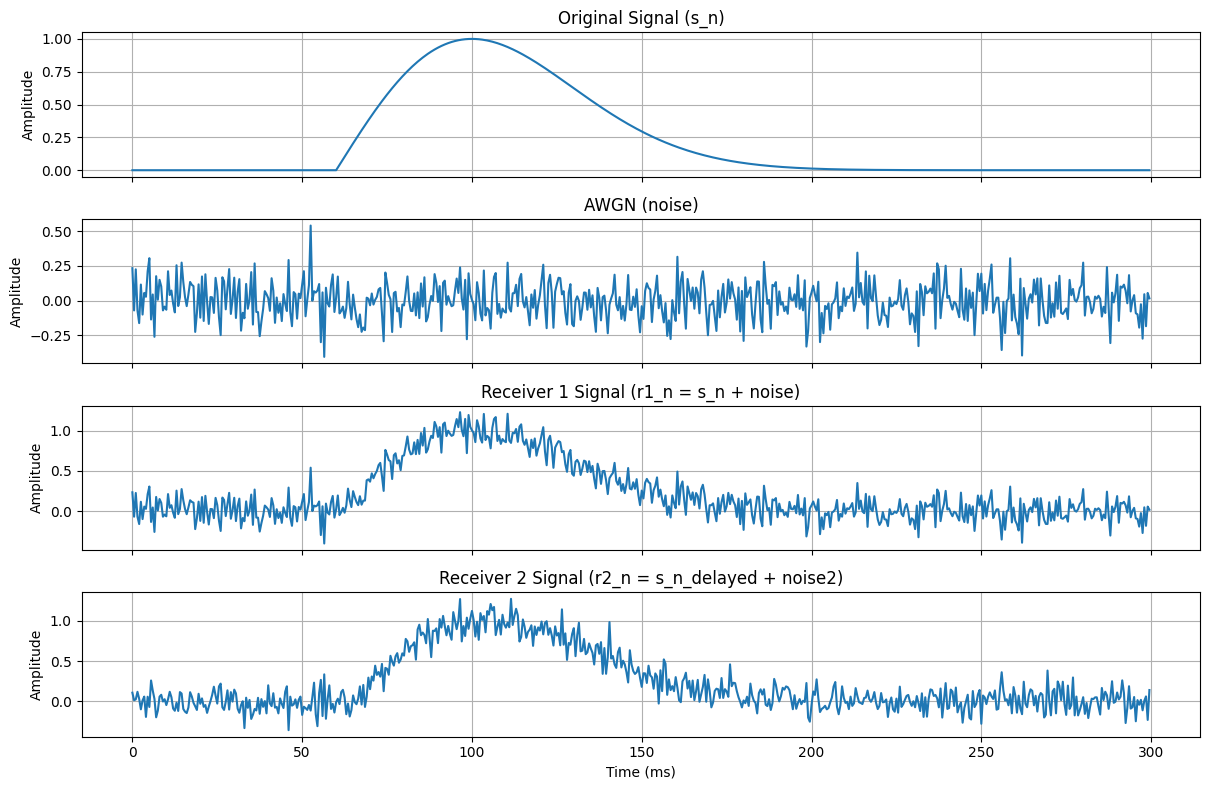

In [29]:

# Call the plotting function for time domain
plot_time_domain_signals(
    t,
    [s_n, noise, r1_n, r2_n],
    ['Original Signal (s_n)', 'AWGN (noise)', 'Receiver 1 Signal (r1_n = s_n + noise)', 'Receiver 2 Signal (r2_n = s_n_delayed + noise2)']
    , fs
)


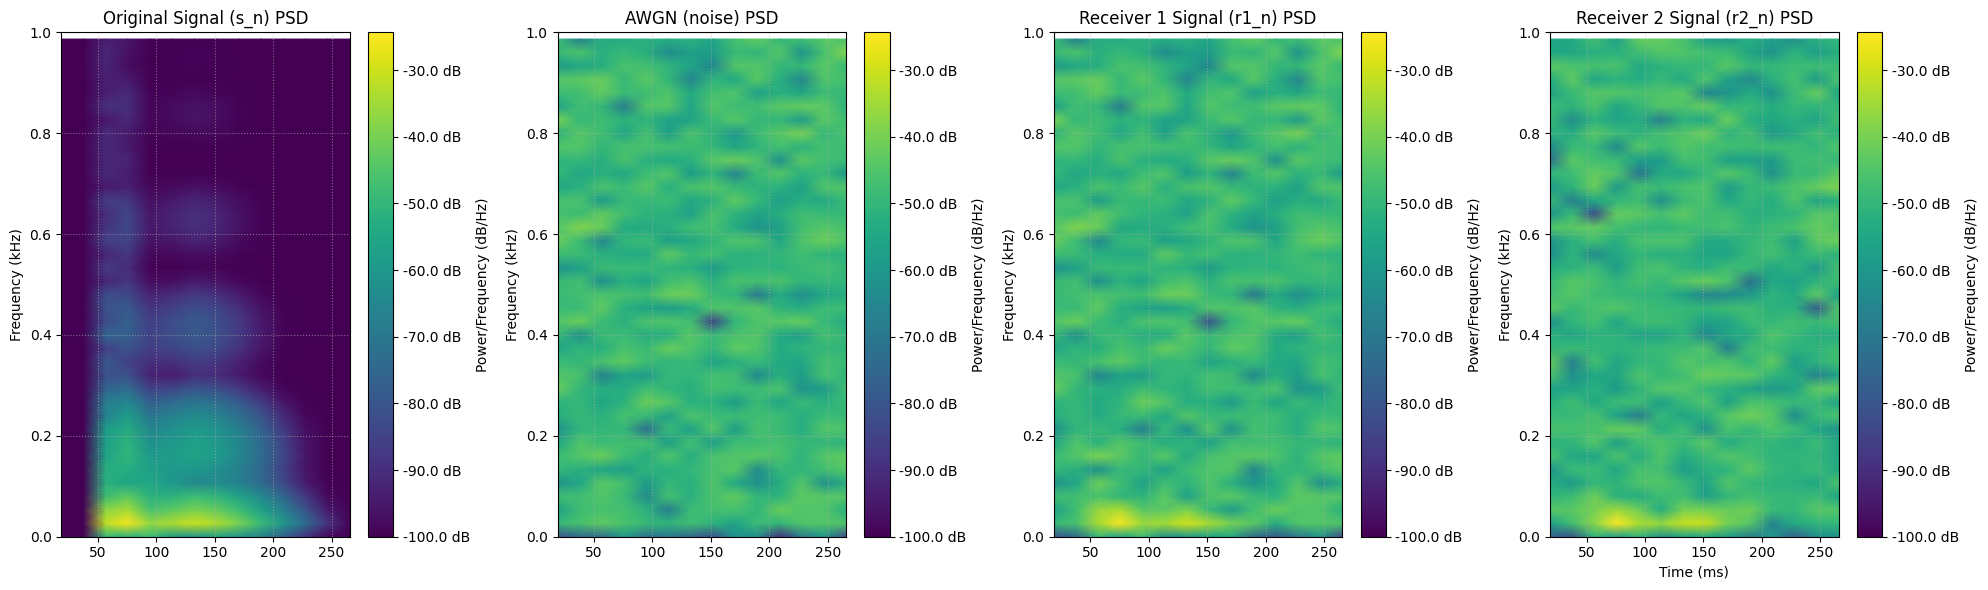

In [32]:
# Call the plotting function for waterfall PSD
plot_waterfall_psd(
    t,
    [s_n, noise, r1_n, r2_n],
    ['Original Signal (s_n) PSD', 'AWGN (noise) PSD', 'Receiver 1 Signal (r1_n) PSD', 'Receiver 2 Signal (r2_n) PSD'],
    fs
)


In [40]:
pulse_spread = 0.005 # Controls the width/spread of the pulse (smaller = wider bandwidth)

# Example usage of the new function
t, s_n, noise, r1_n, r2_n = generate_noisy_signals(
    fs=fs, T=T, delay_t=delay_t,
    pulse_amplitude=pulse_amplitude, pulse_center_time=pulse_center_time, pulse_spread=pulse_spread,
    snr_db=10
)

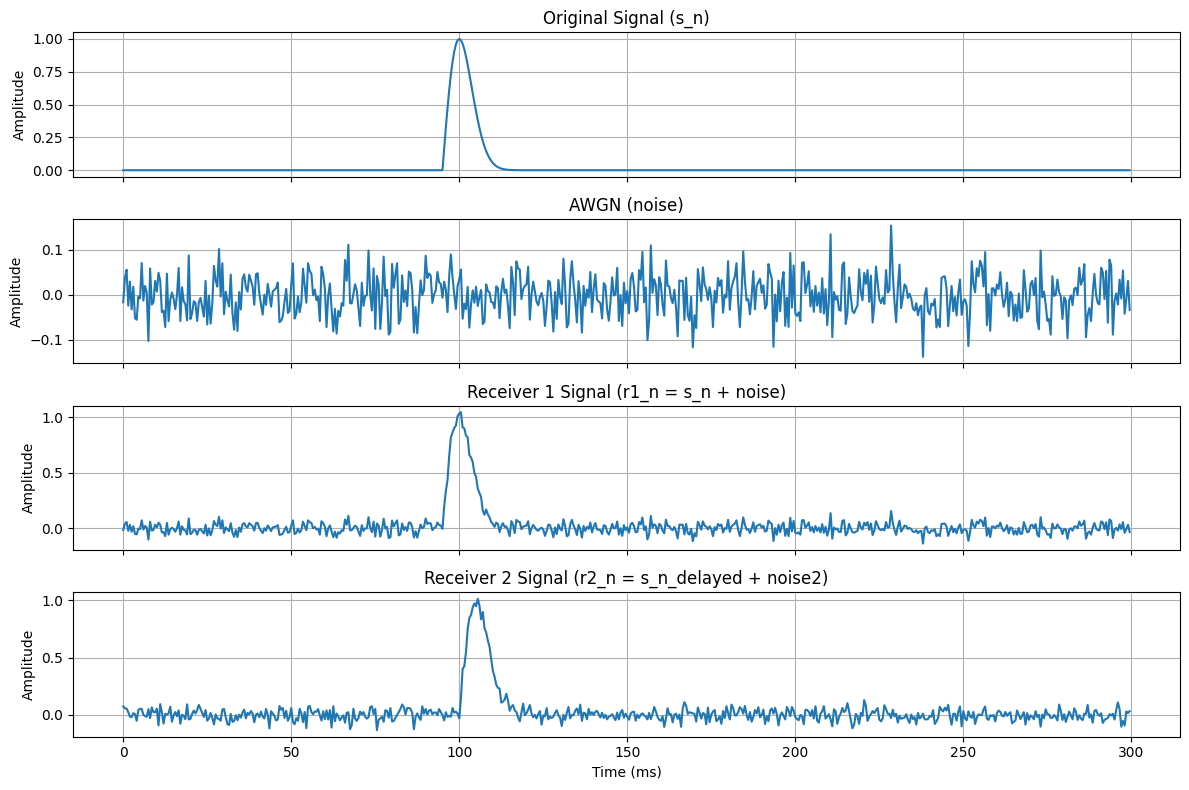

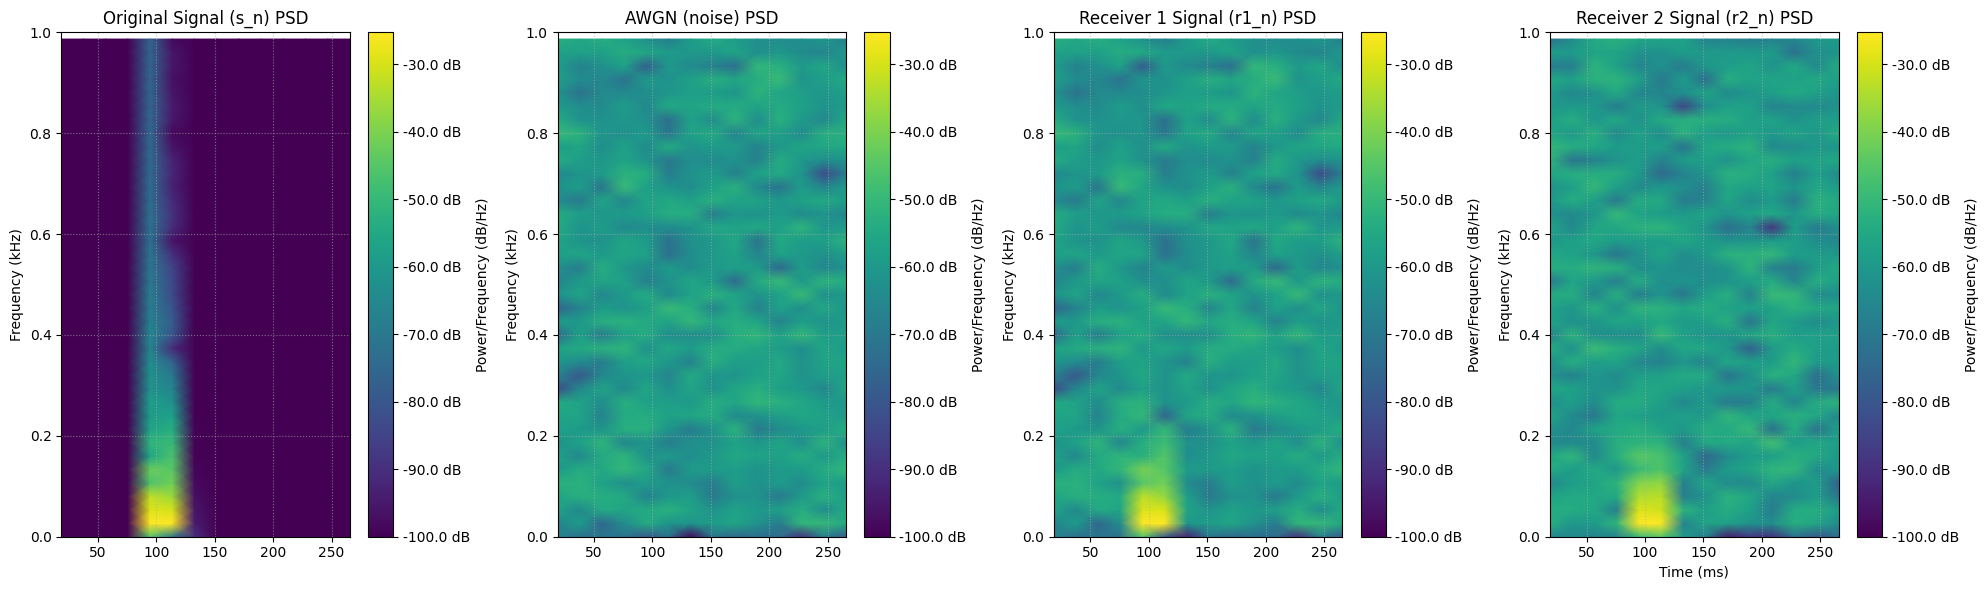

In [41]:
# Call the plotting function for time domain
plot_time_domain_signals(
    t,
    [s_n, noise, r1_n, r2_n],
    ['Original Signal (s_n)', 'AWGN (noise)', 'Receiver 1 Signal (r1_n = s_n + noise)', 'Receiver 2 Signal (r2_n = s_n_delayed + noise2)']
    , fs
)
plot_waterfall_psd(
    t,
    [s_n, noise, r1_n, r2_n],
    ['Original Signal (s_n) PSD', 'AWGN (noise) PSD', 'Receiver 1 Signal (r1_n) PSD', 'Receiver 2 Signal (r2_n) PSD'],
    fs
)